# Homework 03: Learning Curves and Training Workflow

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus.

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll again use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import tensorflow as tf



In [2]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [3]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [4]:
def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training.

In [5]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model,
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    #Compiling the model
    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )


    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()

    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]

    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced.

In [6]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set.


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters.

In [7]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained.

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [8]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [9]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Training with activation: relu

P1 - relu



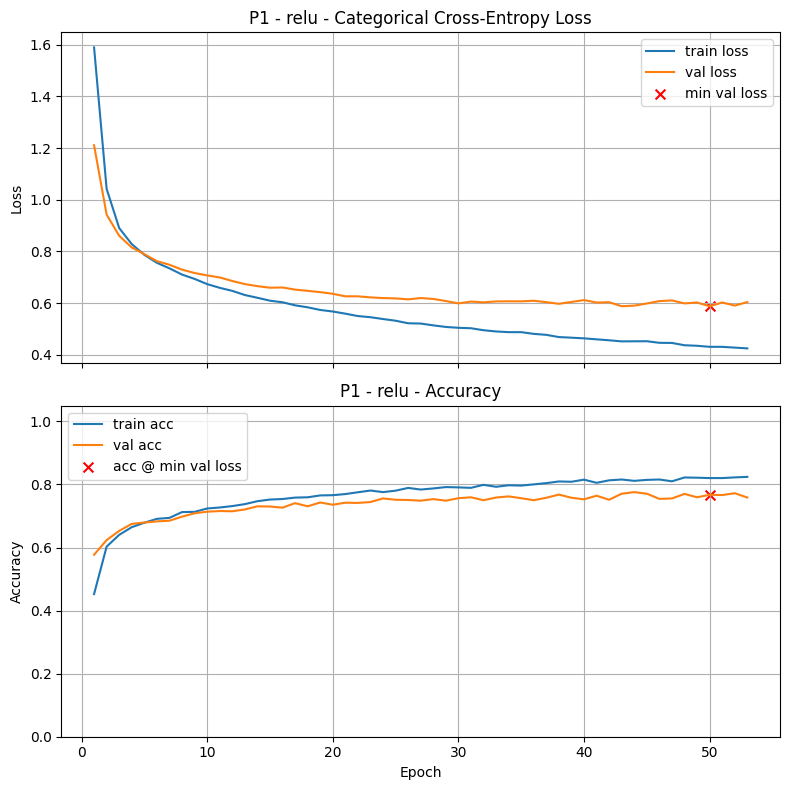

Final Training Loss:            0.4253
Final Training Accuracy:        0.8240
Final Validation Loss:          0.6043
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.5882 (Epoch 50)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6263
Test Accuracy: 0.7471

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:16

Training with activation: sigmoid

P1 - sigmoid



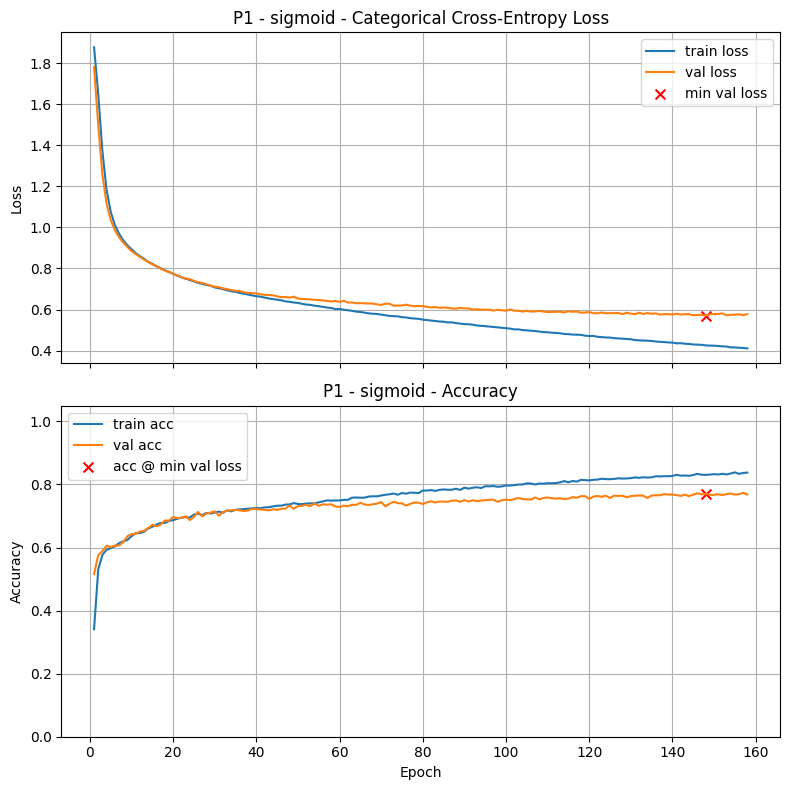

Final Training Loss:            0.4106
Final Training Accuracy:        0.8376
Final Validation Loss:          0.5775
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5704 (Epoch 148)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5781
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:44

Training with activation: tanh

P1 - tanh



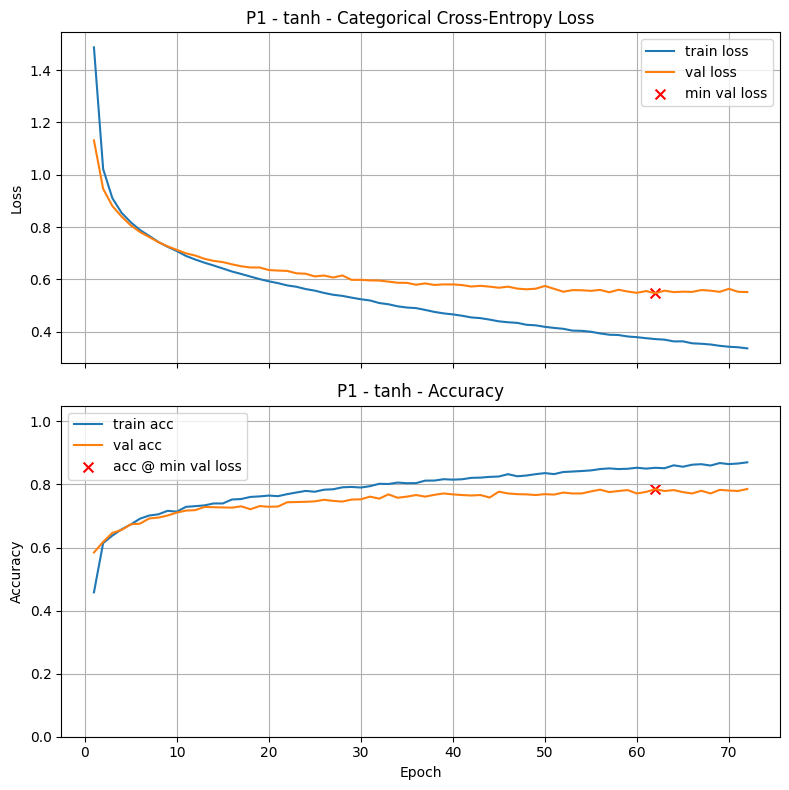

Final Training Loss:            0.3356
Final Training Accuracy:        0.8702
Final Validation Loss:          0.5511
Final Validation Accuracy:      0.7857
Minimum Validation Loss:        0.5466 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7850

Test Loss: 0.5458
Test Accuracy: 0.7729

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:21


(2, 0.7850000262260437)

In [10]:
# Your code here. Add as many cells as you need.
# Problem 1: Activation Function Comparison

activations = ['relu', 'sigmoid', 'tanh']
titles = ['P1 - relu', 'P1 - sigmoid', 'P1 - tanh']
val_accs = []

for act, title in zip(activations, titles):
    model_baseline = build_model(
        X_train.shape[1],
        [
            (64, act, 0.0, 0.0),
            (32, act, 0.0, 0.0)
        ],
        n_classes
    )

    print(f"\nTraining with activation: {act}")
    history = train_and_test(
        model_baseline,
        lr_schedule=0.001,
        title=title,
        return_history=True
    )

    # Extract validation accuracy at min val loss
    val_losses = history.history['val_loss']
    best_epoch = val_losses.index(min(val_losses))
    best_val_acc = history.history['val_accuracy'][best_epoch]
    val_accs.append(best_val_acc)

# Determine best activation
best_index = int(np.argmax(val_accs))
best_activation = best_index   # 0=relu, 1=sigmoid, 2=tanh
best_val_accuracy = val_accs[best_index]

best_index, best_val_accuracy


### Graded Questions

In [11]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 2            # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [12]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a}')


a1a = 2


In [13]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7850            # Replace 0.0 with your answer

In [14]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1b = {a1b:.4f}')

a1b = 0.7850


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



Training with learning rate: 0.001

P2 - lr=0.001



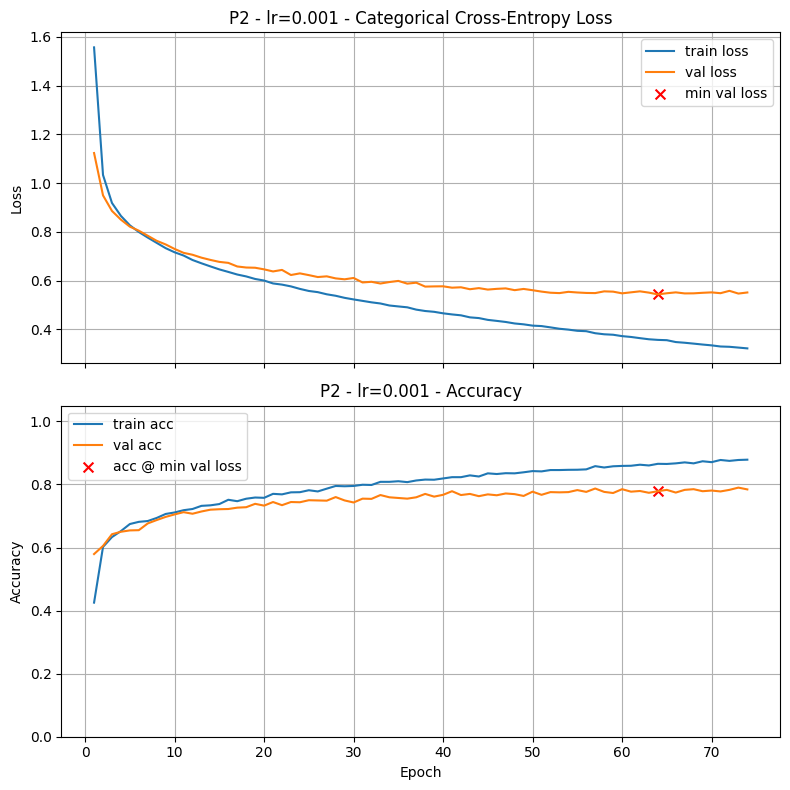

Final Training Loss:            0.3220
Final Training Accuracy:        0.8786
Final Validation Loss:          0.5514
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.5434 (Epoch 64)
Validation Accuracy @ Min Loss: 0.7786

Test Loss: 0.5417
Test Accuracy: 0.7729

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:21

Training with learning rate: 0.0005

P2 - lr=0.0005



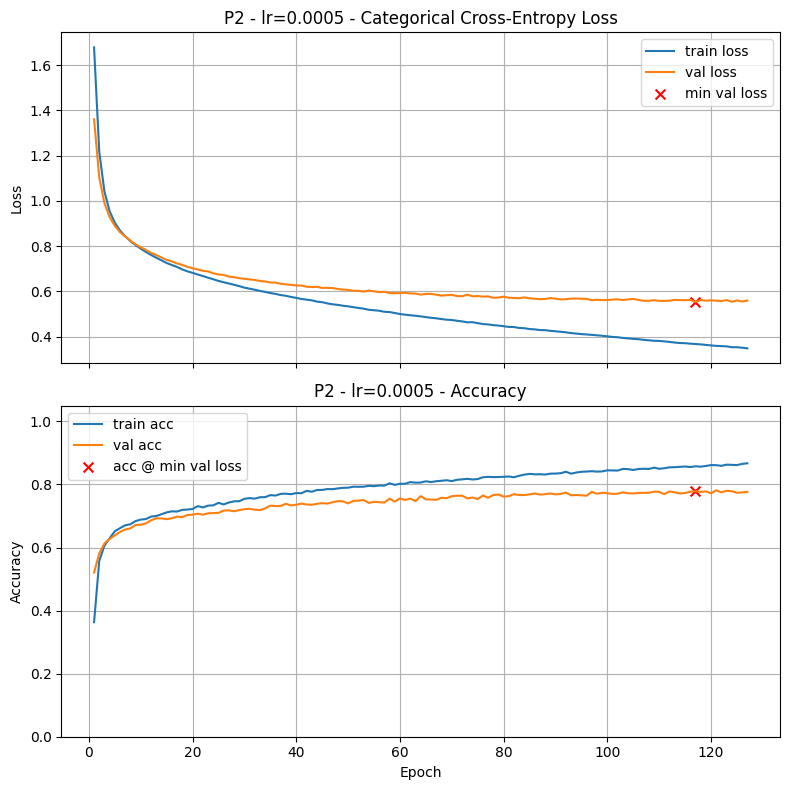

Final Training Loss:            0.3478
Final Training Accuracy:        0.8671
Final Validation Loss:          0.5593
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.5529 (Epoch 117)
Validation Accuracy @ Min Loss: 0.7786

Test Loss: 0.5801
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:37

Training with learning rate: 0.0001

P2 - lr=0.0001



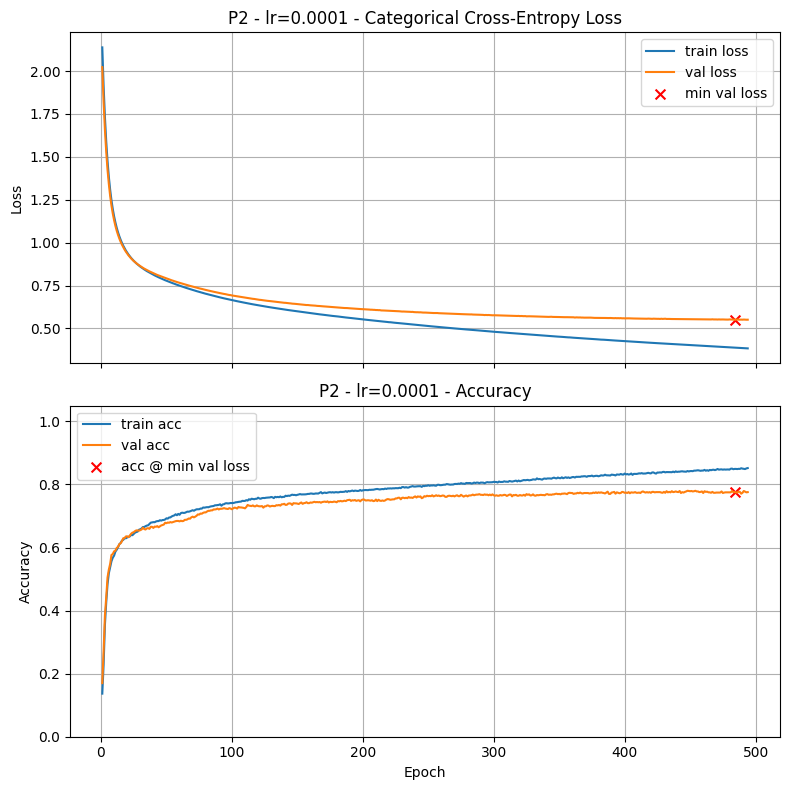

Final Training Loss:            0.3840
Final Training Accuracy:        0.8519
Final Validation Loss:          0.5511
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5509 (Epoch 484)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.5669
Test Accuracy: 0.7771

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:02:18

Training with learning rate: 5e-05

P2 - lr=5e-05



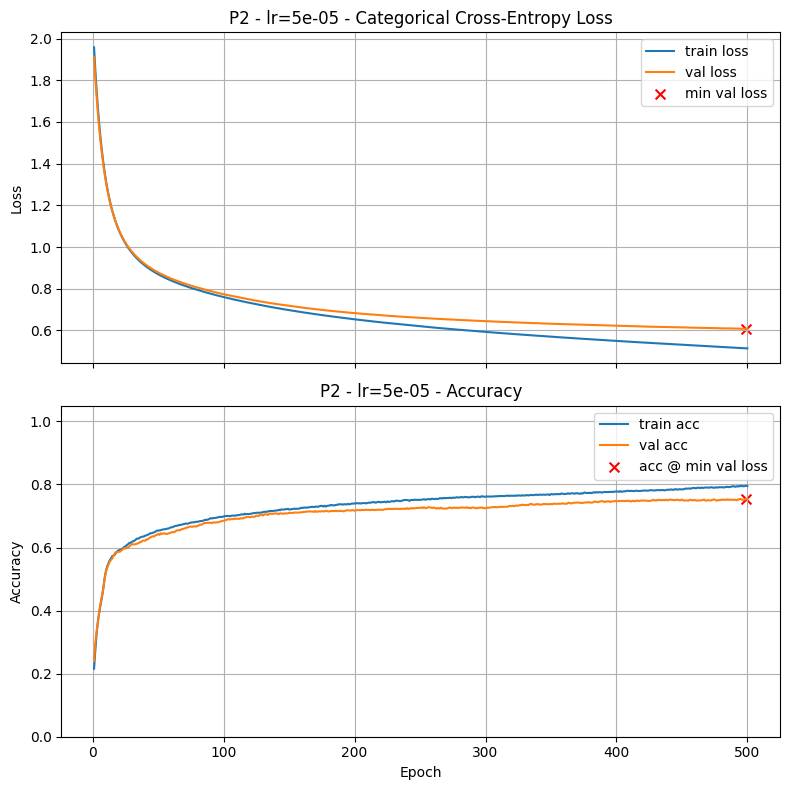

Final Training Loss:            0.5140
Final Training Accuracy:        0.7948
Final Validation Loss:          0.6082
Final Validation Accuracy:      0.7536
Minimum Validation Loss:        0.6080 (Epoch 499)
Validation Accuracy @ Min Loss: 0.7543

Test Loss: 0.6153
Test Accuracy: 0.7386

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:02:19

Training with learning rate: 1e-05

P2 - lr=1e-05



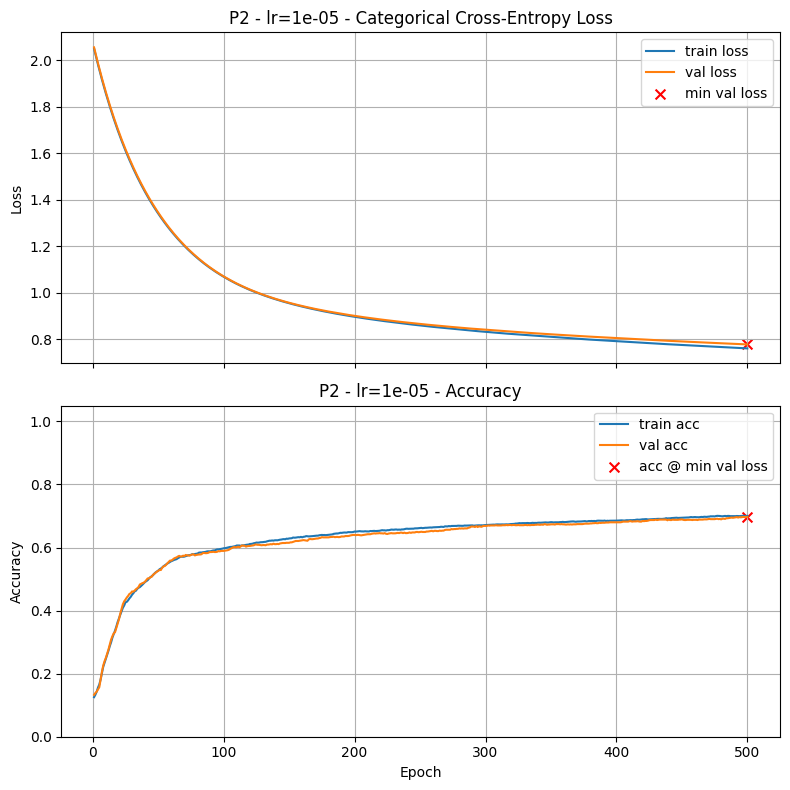

Final Training Loss:            0.7613
Final Training Accuracy:        0.7002
Final Validation Loss:          0.7782
Final Validation Accuracy:      0.6971
Minimum Validation Loss:        0.7782 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6971

Test Loss: 0.7955
Test Accuracy: 0.6871

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:02:19


(0.001, 0.7785714268684387)

In [15]:
# Your code here. Add as many cells as you need.
# Problem 2: Learning Rate Sweep

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
titles = [f"P2 - lr={lr}" for lr in learning_rates]
val_accs = []

for lr, title in zip(learning_rates, titles):
    model_lr = build_model(
        X_train.shape[1],
        [
            (64, 'tanh', 0.0, 0.0),
            (32, 'tanh', 0.0, 0.0)
        ],
        n_classes
    )

    print(f"\nTraining with learning rate: {lr}")
    history = train_and_test(
        model_lr,
        lr_schedule=lr,
        title=title,
        epochs=500,
        return_history=True
    )

    # Extract validation accuracy at min val loss
    val_losses = history.history['val_loss']
    best_epoch = val_losses.index(min(val_losses))
    best_val_acc = history.history['val_accuracy'][best_epoch]
    val_accs.append(best_val_acc)

# Determine best learning rate
best_index = int(np.argmax(val_accs))
best_lr = learning_rates[best_index]
best_val_accuracy = val_accs[best_index]

best_lr, best_val_accuracy


#### Graded Questions

In [16]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 0.001          # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a:.6f}')

a2a = 0.001000


In [18]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.7786            # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.7786


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



P3 - d1=0.0, d2=0.0



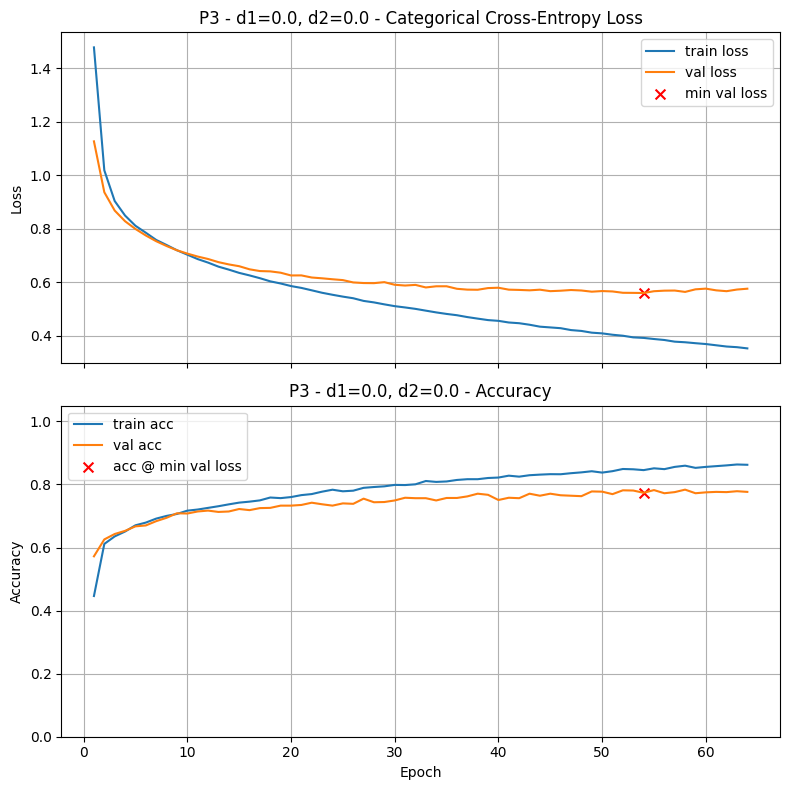

Final Training Loss:            0.3522
Final Training Accuracy:        0.8624
Final Validation Loss:          0.5756
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.5595 (Epoch 54)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.5662
Test Accuracy: 0.7700

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:20

P3 - d1=0.0, d2=0.1



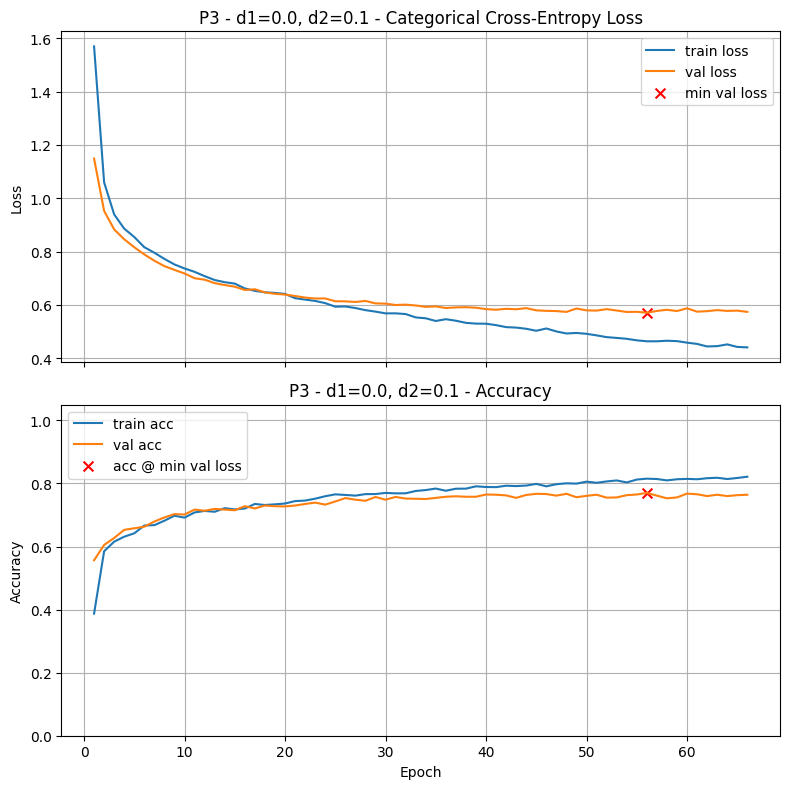

Final Training Loss:            0.4404
Final Training Accuracy:        0.8214
Final Validation Loss:          0.5736
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5704 (Epoch 56)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5853
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:22

P3 - d1=0.0, d2=0.2



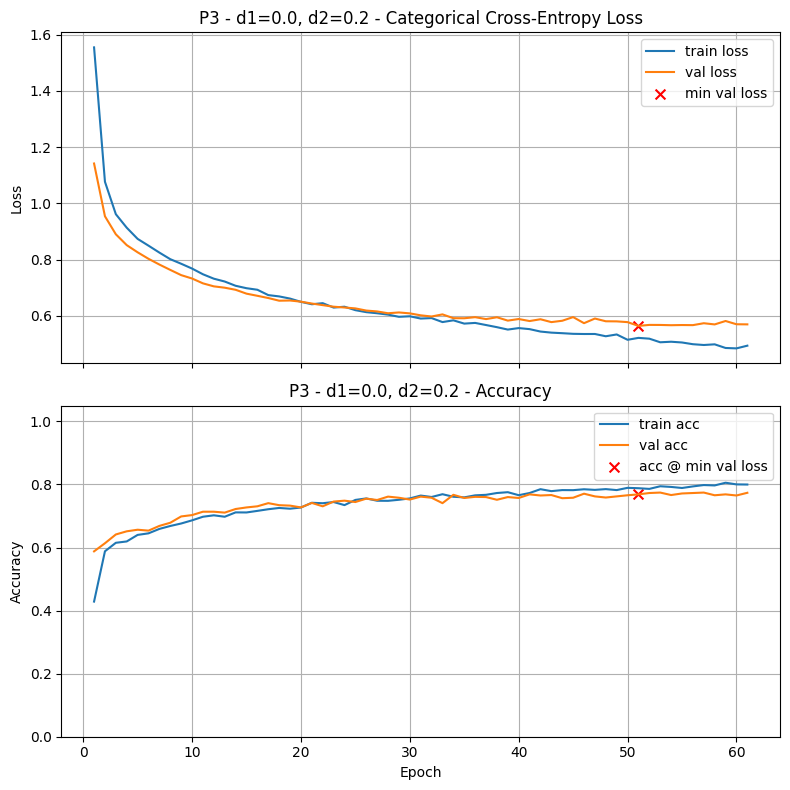

Final Training Loss:            0.4944
Final Training Accuracy:        0.7998
Final Validation Loss:          0.5701
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5647 (Epoch 51)
Validation Accuracy @ Min Loss: 0.7686

Test Loss: 0.5992
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:19

P3 - d1=0.0, d2=0.3



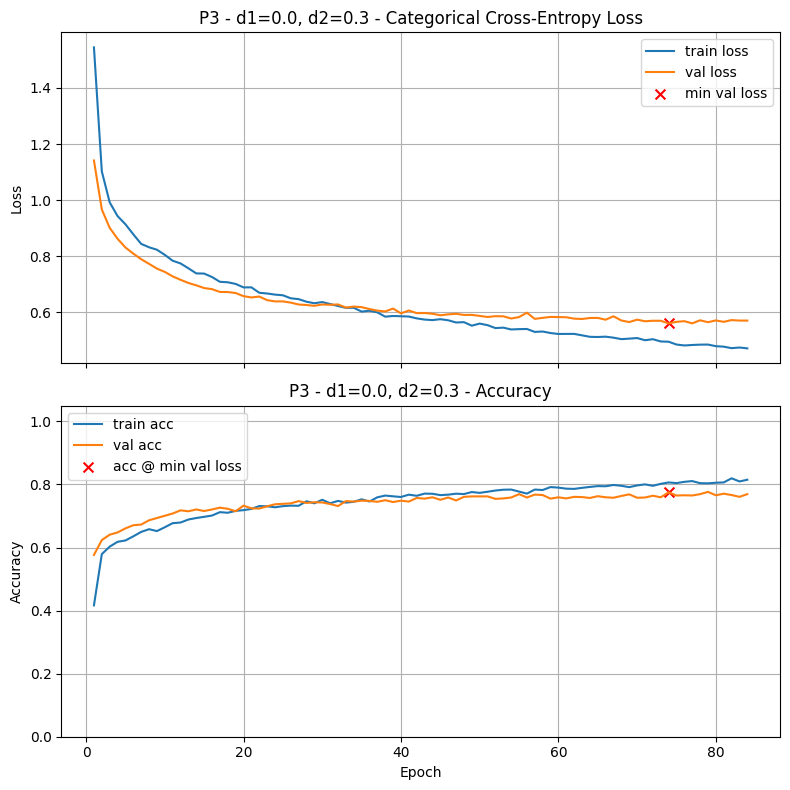

Final Training Loss:            0.4712
Final Training Accuracy:        0.8150
Final Validation Loss:          0.5703
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.5602 (Epoch 74)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.5955
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:26

P3 - d1=0.0, d2=0.4



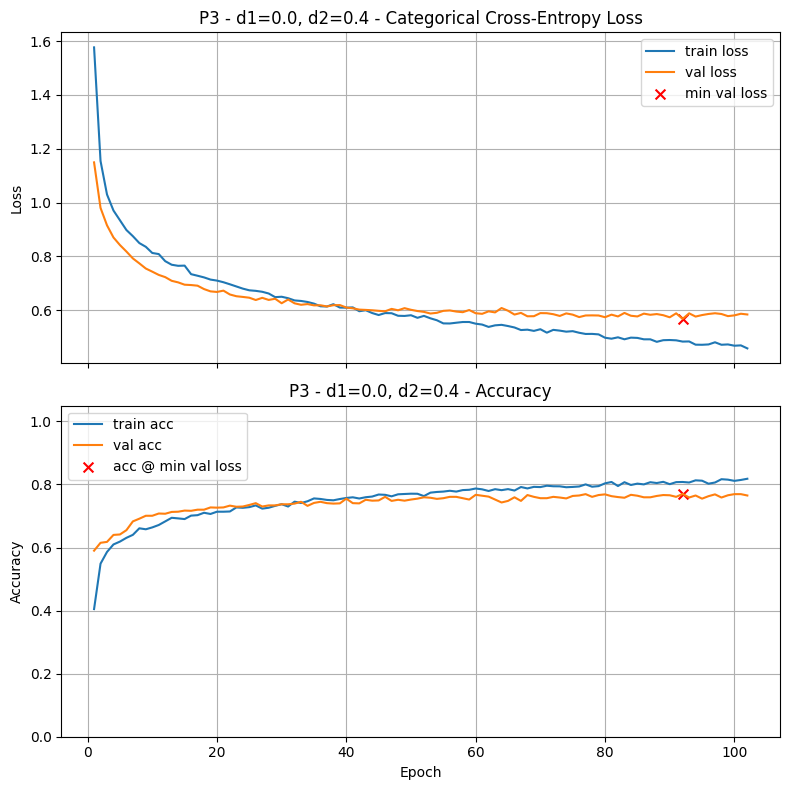

Final Training Loss:            0.4580
Final Training Accuracy:        0.8181
Final Validation Loss:          0.5840
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5677 (Epoch 92)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5962
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:33

P3 - d1=0.0, d2=0.5



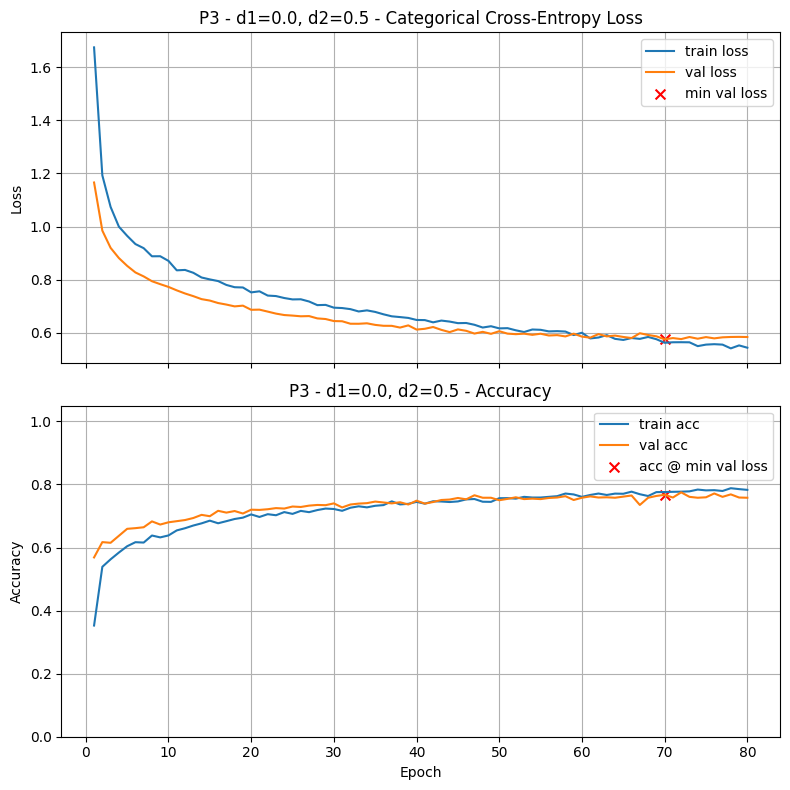

Final Training Loss:            0.5443
Final Training Accuracy:        0.7829
Final Validation Loss:          0.5845
Final Validation Accuracy:      0.7579
Minimum Validation Loss:        0.5759 (Epoch 70)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6182
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:25

P3 - d1=0.1, d2=0.0



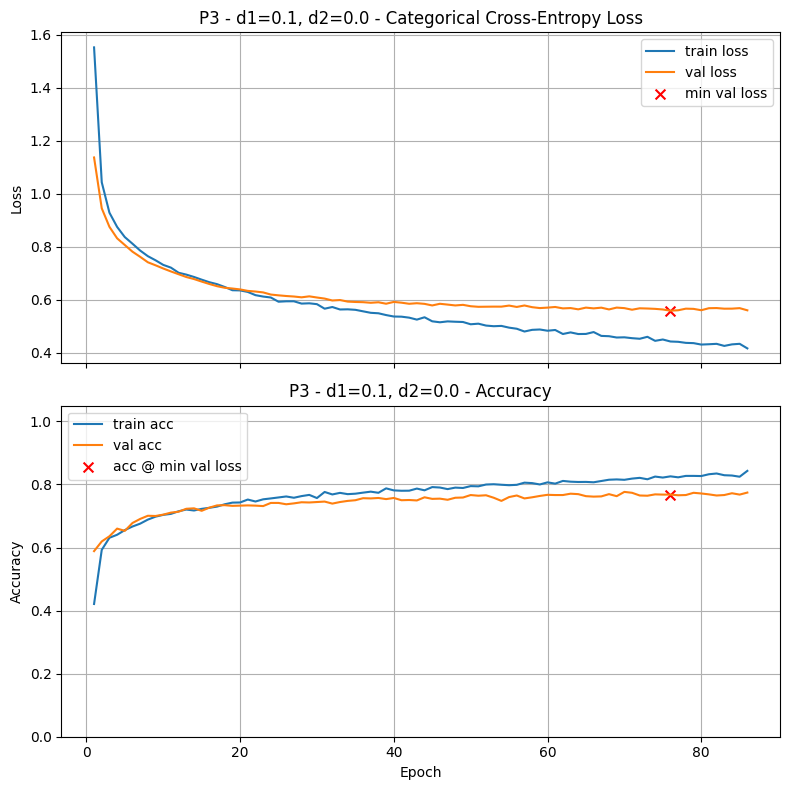

Final Training Loss:            0.4156
Final Training Accuracy:        0.8431
Final Validation Loss:          0.5593
Final Validation Accuracy:      0.7743
Minimum Validation Loss:        0.5579 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.5932
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:00:25

P3 - d1=0.1, d2=0.1



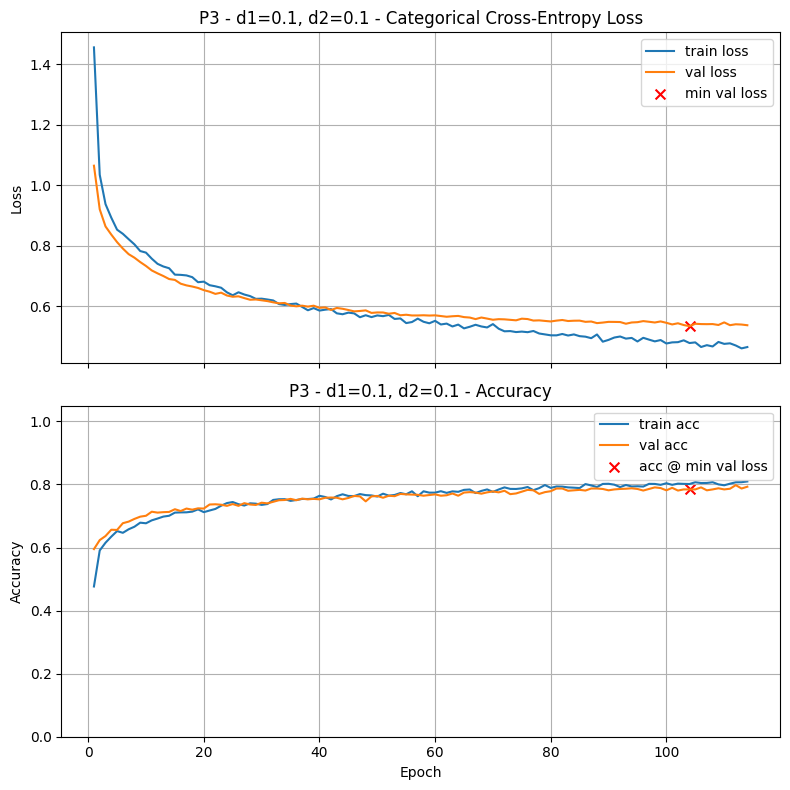

Final Training Loss:            0.4656
Final Training Accuracy:        0.8095
Final Validation Loss:          0.5377
Final Validation Accuracy:      0.7929
Minimum Validation Loss:        0.5346 (Epoch 104)
Validation Accuracy @ Min Loss: 0.7843

Test Loss: 0.5636
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:34

P3 - d1=0.1, d2=0.2



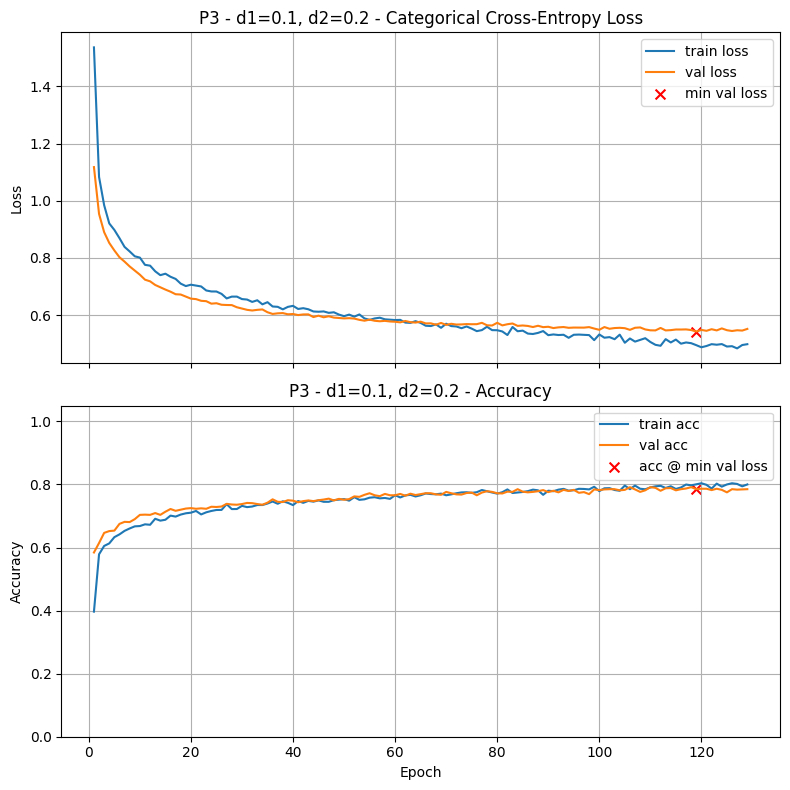

Final Training Loss:            0.4981
Final Training Accuracy:        0.8000
Final Validation Loss:          0.5516
Final Validation Accuracy:      0.7850
Minimum Validation Loss:        0.5425 (Epoch 119)
Validation Accuracy @ Min Loss: 0.7850

Test Loss: 0.5760
Test Accuracy: 0.7671

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:39

P3 - d1=0.1, d2=0.3



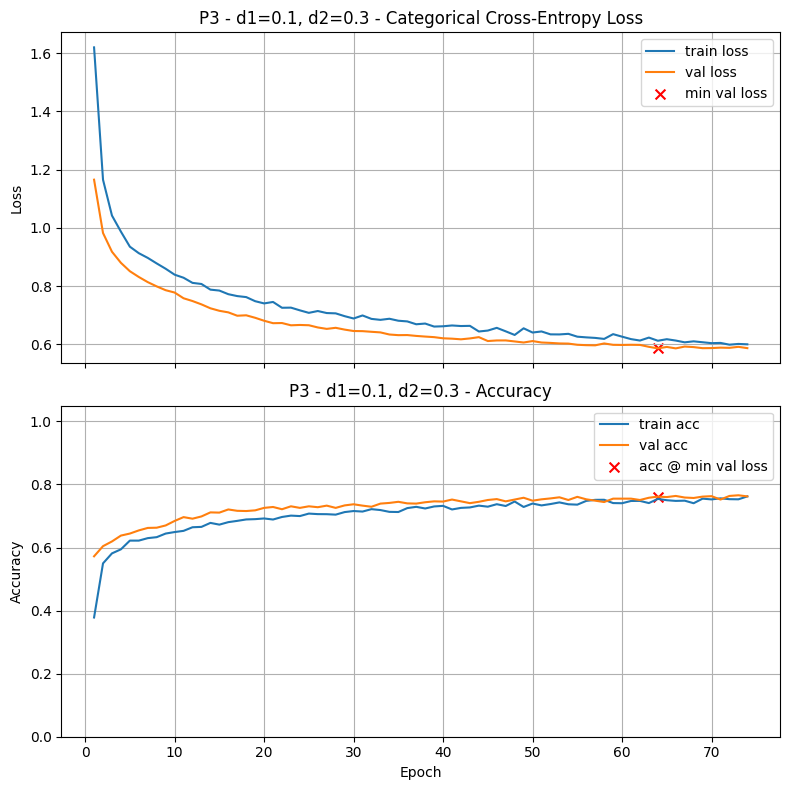

Final Training Loss:            0.5997
Final Training Accuracy:        0.7621
Final Validation Loss:          0.5866
Final Validation Accuracy:      0.7621
Minimum Validation Loss:        0.5858 (Epoch 64)
Validation Accuracy @ Min Loss: 0.7614

Test Loss: 0.6173
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:23

P3 - d1=0.1, d2=0.4



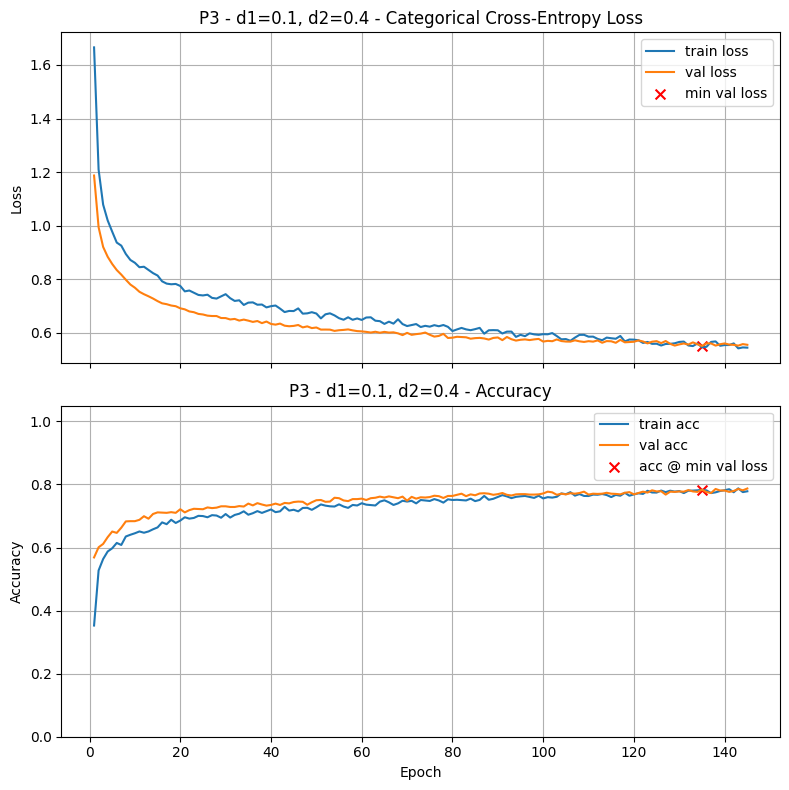

Final Training Loss:            0.5443
Final Training Accuracy:        0.7783
Final Validation Loss:          0.5550
Final Validation Accuracy:      0.7871
Minimum Validation Loss:        0.5506 (Epoch 135)
Validation Accuracy @ Min Loss: 0.7836

Test Loss: 0.5863
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:43

P3 - d1=0.1, d2=0.5



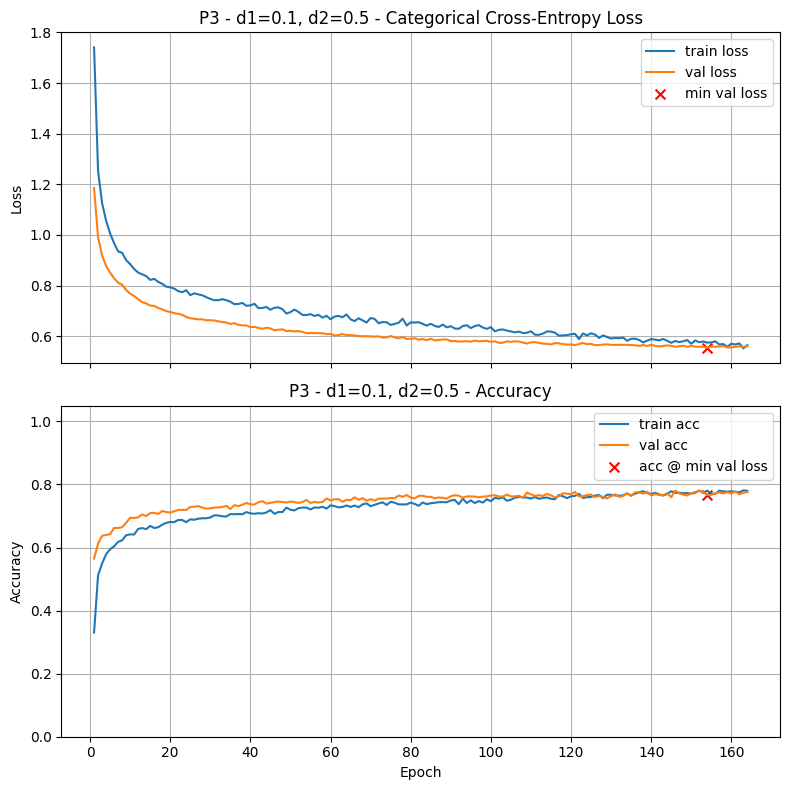

Final Training Loss:            0.5643
Final Training Accuracy:        0.7798
Final Validation Loss:          0.5602
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5547 (Epoch 154)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.5895
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:48

P3 - d1=0.2, d2=0.0



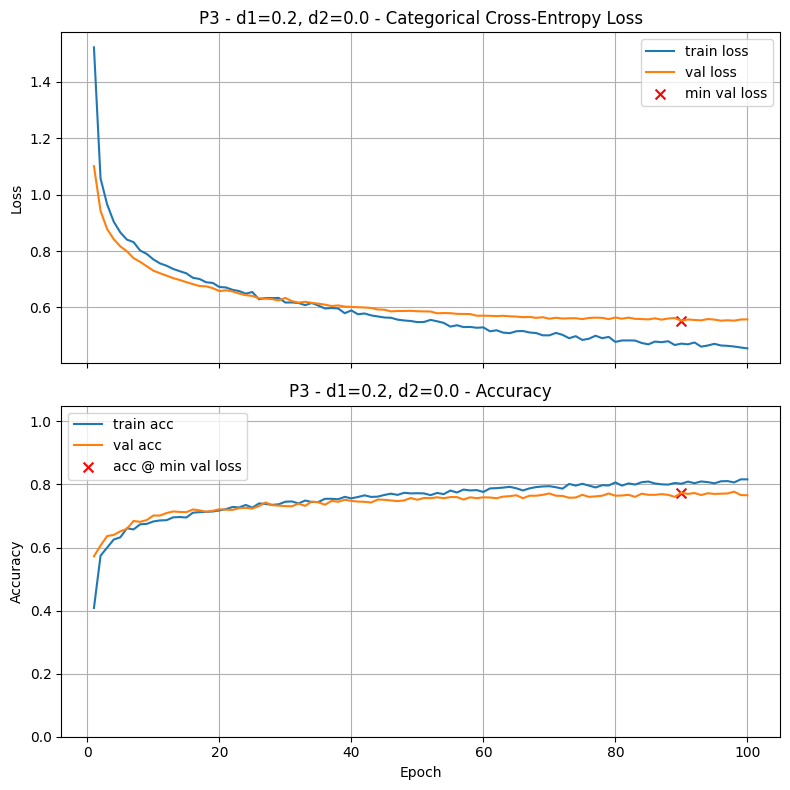

Final Training Loss:            0.4549
Final Training Accuracy:        0.8162
Final Validation Loss:          0.5577
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5531 (Epoch 90)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.5811
Test Accuracy: 0.7507

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:00:28

P3 - d1=0.2, d2=0.1



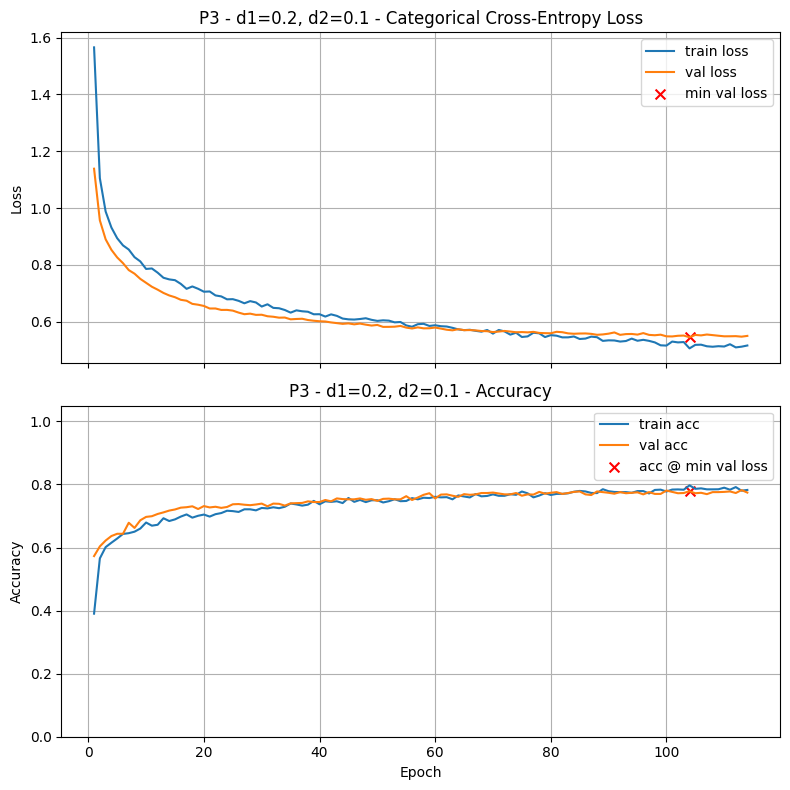

Final Training Loss:            0.5161
Final Training Accuracy:        0.7826
Final Validation Loss:          0.5499
Final Validation Accuracy:      0.7743
Minimum Validation Loss:        0.5451 (Epoch 104)
Validation Accuracy @ Min Loss: 0.7786

Test Loss: 0.5751
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:00:34

P3 - d1=0.2, d2=0.2



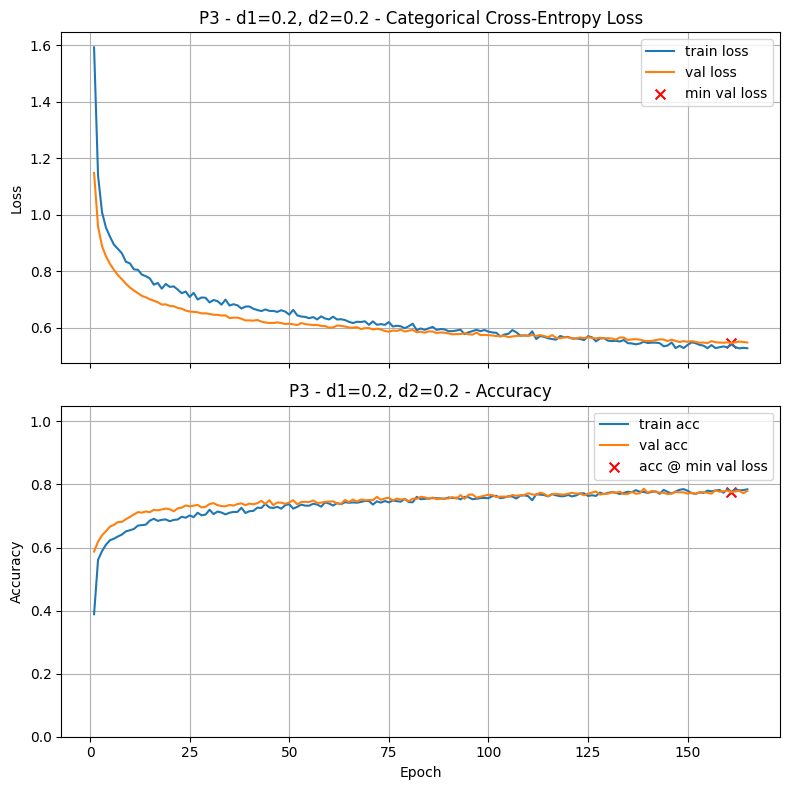

Final Training Loss:            0.5270
Final Training Accuracy:        0.7845
Final Validation Loss:          0.5474
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5452 (Epoch 161)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.5786
Test Accuracy: 0.7707

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:48

P3 - d1=0.2, d2=0.3



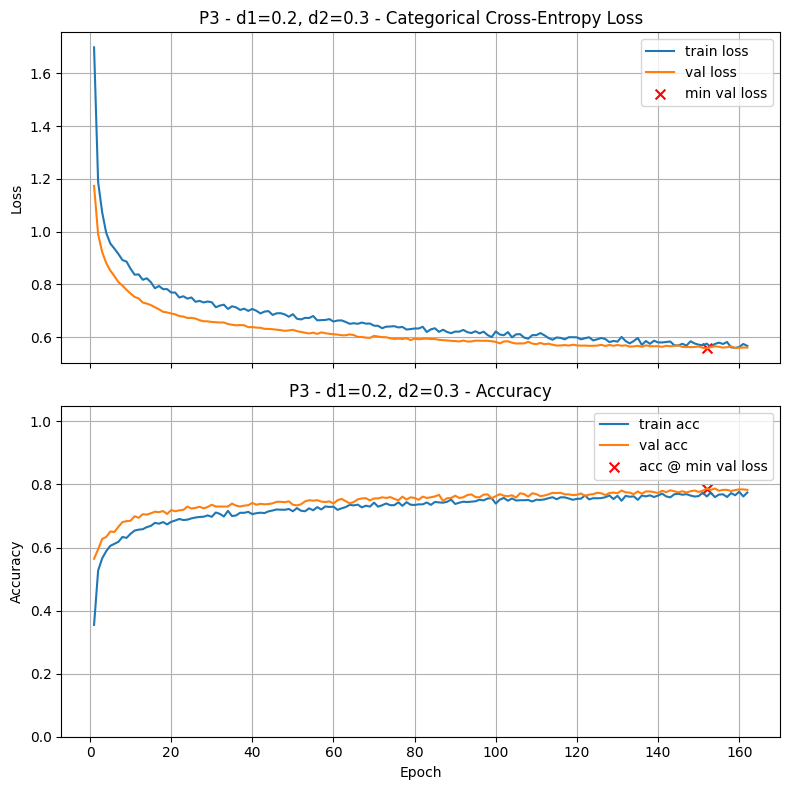

Final Training Loss:            0.5672
Final Training Accuracy:        0.7745
Final Validation Loss:          0.5608
Final Validation Accuracy:      0.7829
Minimum Validation Loss:        0.5578 (Epoch 152)
Validation Accuracy @ Min Loss: 0.7871

Test Loss: 0.5885
Test Accuracy: 0.7686

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:52

P3 - d1=0.2, d2=0.4



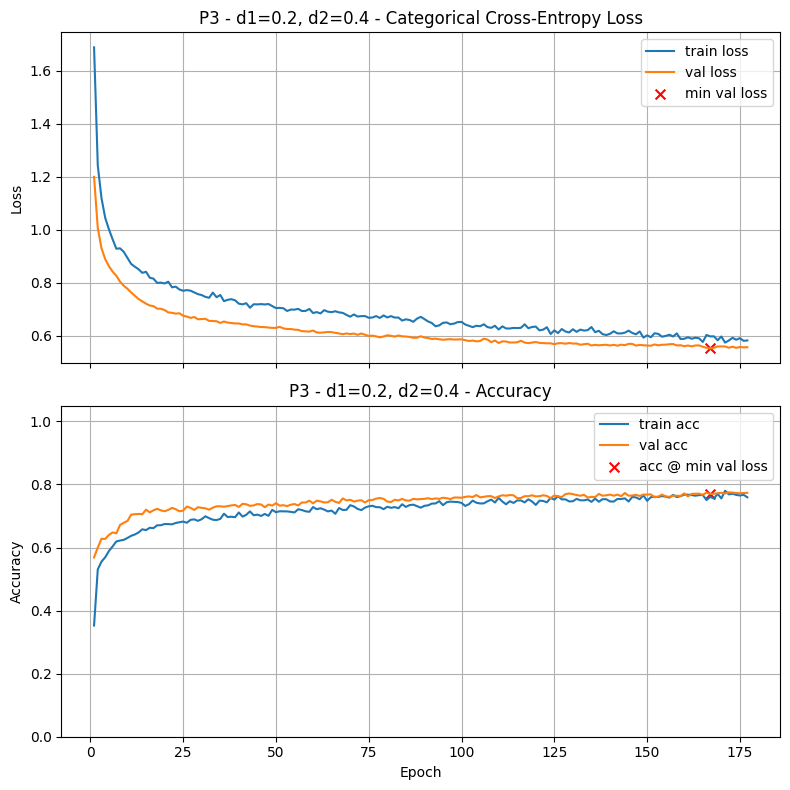

Final Training Loss:            0.5830
Final Training Accuracy:        0.7593
Final Validation Loss:          0.5574
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5530 (Epoch 167)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5959
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:00:55

P3 - d1=0.2, d2=0.5



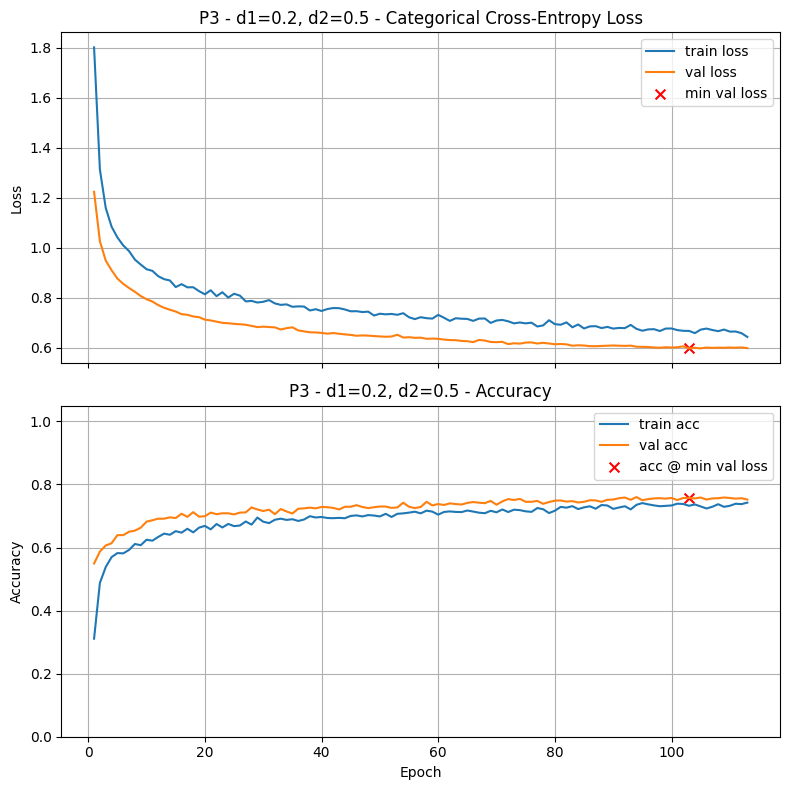

Final Training Loss:            0.6426
Final Training Accuracy:        0.7424
Final Validation Loss:          0.5977
Final Validation Accuracy:      0.7521
Minimum Validation Loss:        0.5967 (Epoch 103)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.6341
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:35


TypeError: '>' not supported between instances of 'float' and 'tuple'

In [20]:
# Your code here. Add as many cells as you need.
# Problem 3: Dropout Sweep

dropout_64 = [0.0, 0.1, 0.2]
dropout_32 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

results = {}

for d1 in dropout_64:
    for d2 in dropout_32:
        title = f"P3 - d1={d1}, d2={d2}"
        model = build_model(
            X_train.shape[1],
            [
                (64, 'tanh', 0.0, d1),
                (32, 'tanh', 0.0, d2)
            ],
            n_classes
        )

        history = train_and_test(
            model,
            lr_schedule=0.001,
            title=title,
            return_history=True
        )

        # Extract validation accuracy at min val loss
        val_losses = history.history['val_loss']
        best_epoch = val_losses.index(min(val_losses))
        best_val_acc = history.history['val_accuracy'][best_epoch]

        results[(d1, d2)] = best_val_acc

# Find best dropout pair
best_pair = max(results, key=results.get)
best_acc = results[best_pair]

best_pair, best_acc


In [21]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best
# validation accuracy at the epoch of minimum validation loss

a3a = (0.2, 0.3)           # Replace (0.0,0.0) with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a}')

a3a = (0.2, 0.3)


In [23]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7871            # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.7871


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simply by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Testing: P4 - L2 (0.0001, 0.0001)

P4 - L2 (0.0001, 0.0001)



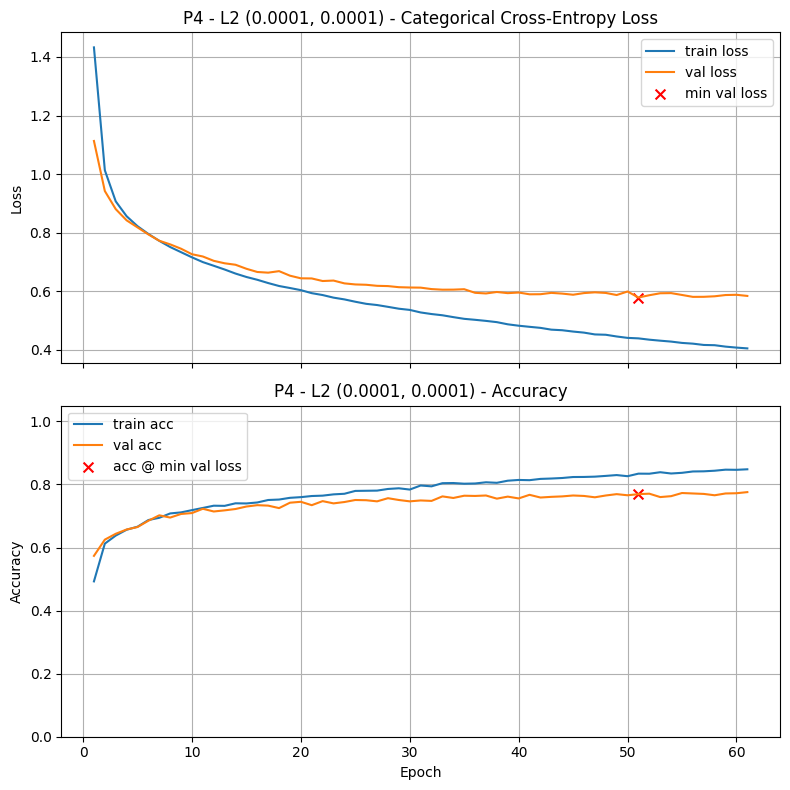

Final Training Loss:            0.4049
Final Training Accuracy:        0.8481
Final Validation Loss:          0.5840
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5786 (Epoch 51)
Validation Accuracy @ Min Loss: 0.7693

Test Loss: 0.6016
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:18

Testing: P4 - L2 (0.001, 0.001)

P4 - L2 (0.001, 0.001)



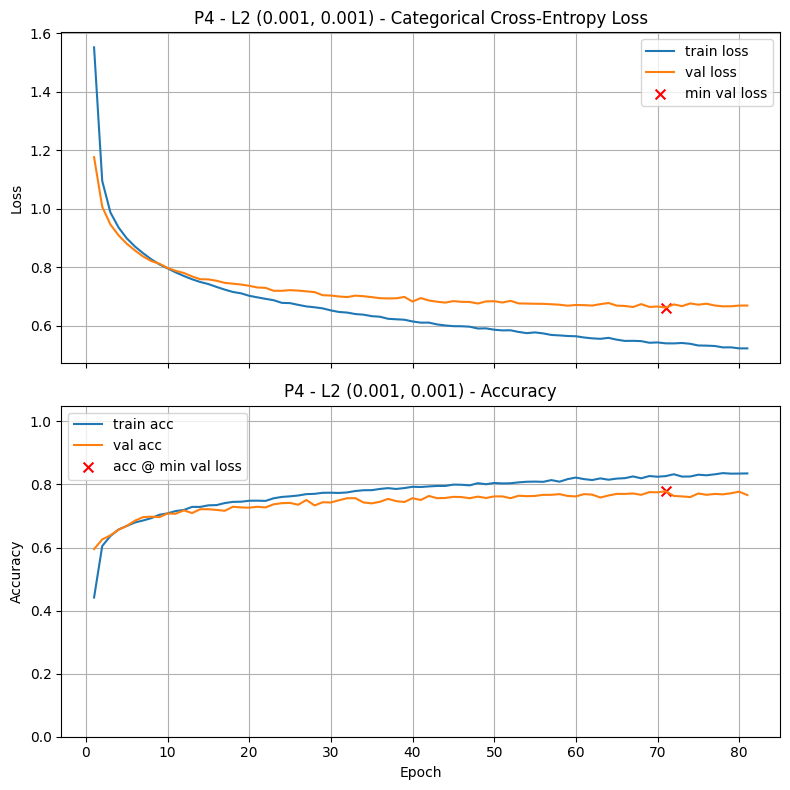

Final Training Loss:            0.5225
Final Training Accuracy:        0.8350
Final Validation Loss:          0.6689
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.6623 (Epoch 71)
Validation Accuracy @ Min Loss: 0.7786

Test Loss: 0.6735
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:24

Testing: P4 - L2 (0.01, 0.01)

P4 - L2 (0.01, 0.01)



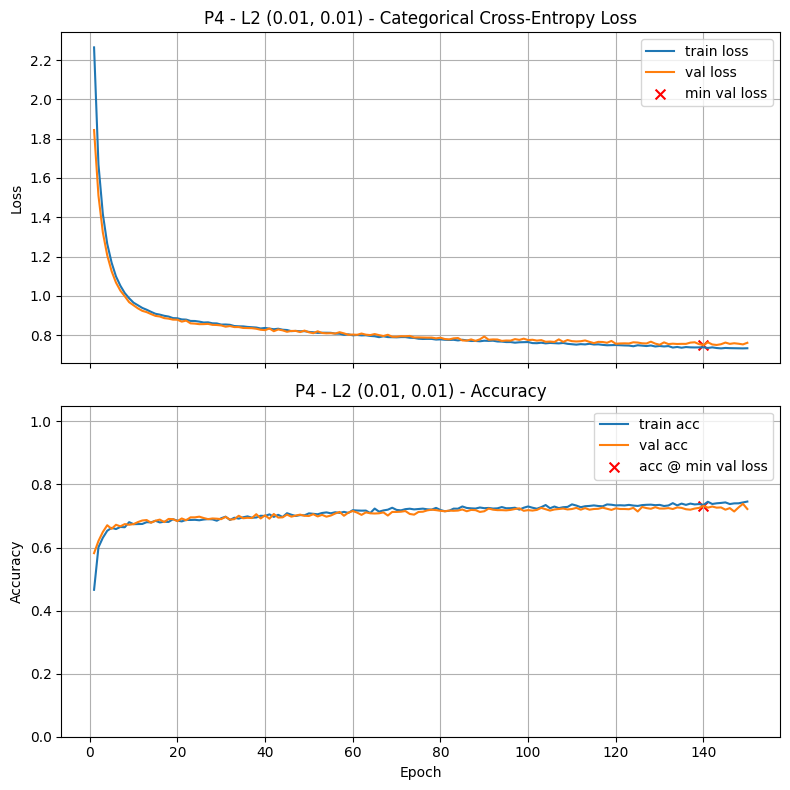

Final Training Loss:            0.7331
Final Training Accuracy:        0.7457
Final Validation Loss:          0.7609
Final Validation Accuracy:      0.7221
Minimum Validation Loss:        0.7497 (Epoch 140)
Validation Accuracy @ Min Loss: 0.7321

Test Loss: 0.7707
Test Accuracy: 0.7279

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:45

Testing: P4 - L2 (0.0001, 0.001)

P4 - L2 (0.0001, 0.001)



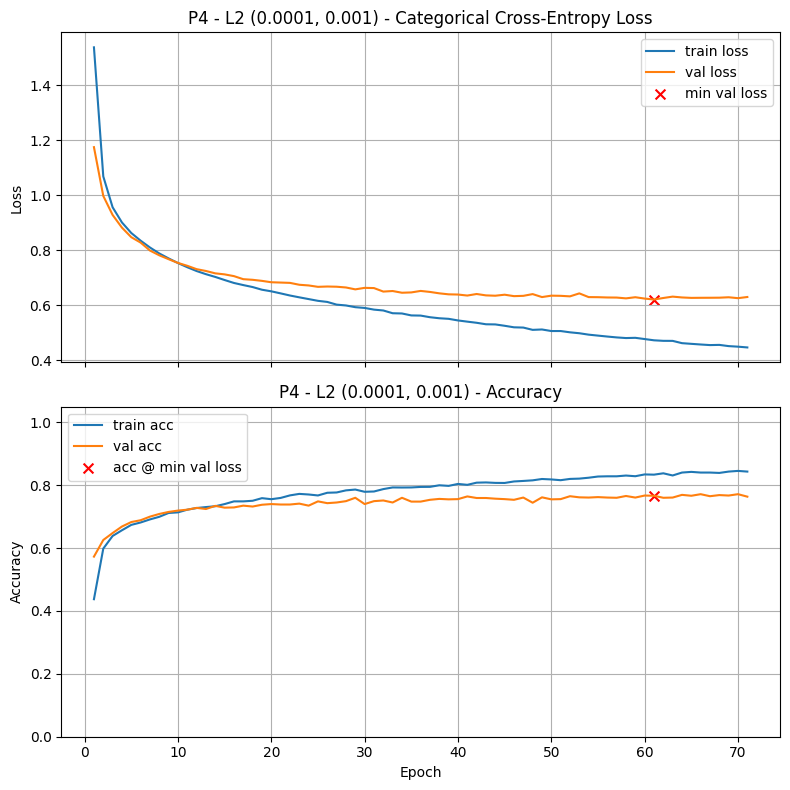

Final Training Loss:            0.4473
Final Training Accuracy:        0.8433
Final Validation Loss:          0.6304
Final Validation Accuracy:      0.7636
Minimum Validation Loss:        0.6213 (Epoch 61)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6459
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:21


((0.001, 0.001), 0.7785714268684387)

In [26]:
# Problem 4: L2 Regularization

l2_pairs = [
    (1e-4, 1e-4),
    (1e-3, 1e-3),
    (1e-2, 1e-2),
    (1e-4, 1e-3)
]

results_l2 = {}

for l1, l2 in l2_pairs:
    title = f"P4 - L2 ({l1}, {l2})"
    print("\nTesting:", title)

    model = build_model(
        X_train.shape[1],
        [
            (64, 'tanh', l1, 0.0),
            (32, 'tanh', l2, 0.0)
        ],
        n_classes
    )

    history = train_and_test(
        model,
        lr_schedule=0.001,
        title=title,
        epochs=200,          # Faster!
        return_history=True,
        verbose=0
    )

    val_losses = history.history['val_loss']
    best_epoch = val_losses.index(min(val_losses))
    best_val_acc = history.history['val_accuracy'][best_epoch]

    results_l2[(l1, l2)] = best_val_acc

# Find best L2 pair
best_l2_pair = max(results_l2, key=results_l2.get)
best_l2_acc = results_l2[best_l2_pair]

best_l2_pair, best_l2_acc


In [27]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best
# validation accuracy at the epoch of minimum validation loss

a4a = (0.001, 0.001)            # Replace (0.0,0.0) with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a}')

a4a = (0.001, 0.001)


In [30]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7786            # Replace 0.0 with your answer

In [31]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.7786


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




Testing: P5 - dropout(0.2,0.3) + L2(0.0001,0.0001)

P5 - dropout(0.2,0.3) + L2(0.0001,0.0001)



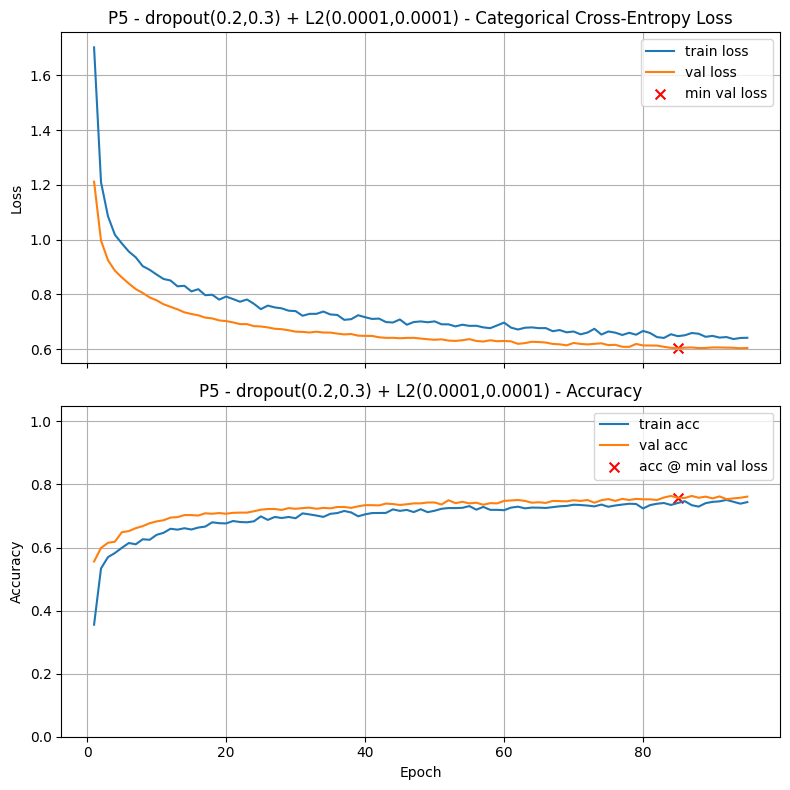

Final Training Loss:            0.6419
Final Training Accuracy:        0.7440
Final Validation Loss:          0.6047
Final Validation Accuracy:      0.7614
Minimum Validation Loss:        0.6032 (Epoch 85)
Validation Accuracy @ Min Loss: 0.7579

Test Loss: 0.6274
Test Accuracy: 0.7457

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:28

Testing: P5 - dropout(0.2,0.3) + L2(0.001,0.001)

P5 - dropout(0.2,0.3) + L2(0.001,0.001)



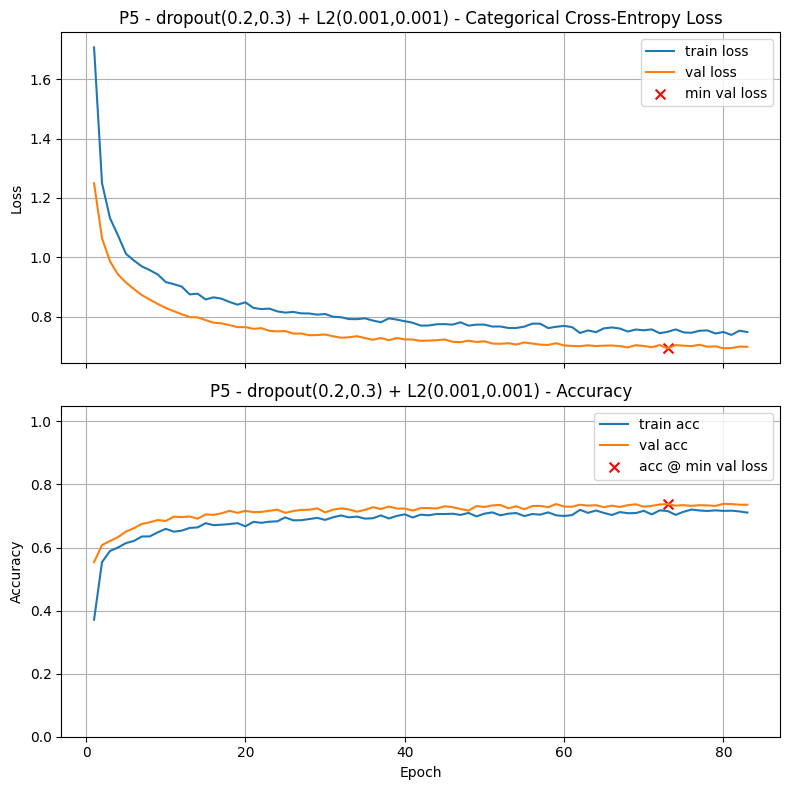

Final Training Loss:            0.7479
Final Training Accuracy:        0.7107
Final Validation Loss:          0.6981
Final Validation Accuracy:      0.7357
Minimum Validation Loss:        0.6928 (Epoch 73)
Validation Accuracy @ Min Loss: 0.7379

Test Loss: 0.7204
Test Accuracy: 0.7336

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:25

Testing: P5 - dropout(0.2,0.3) + L2(0.01,0.01)

P5 - dropout(0.2,0.3) + L2(0.01,0.01)



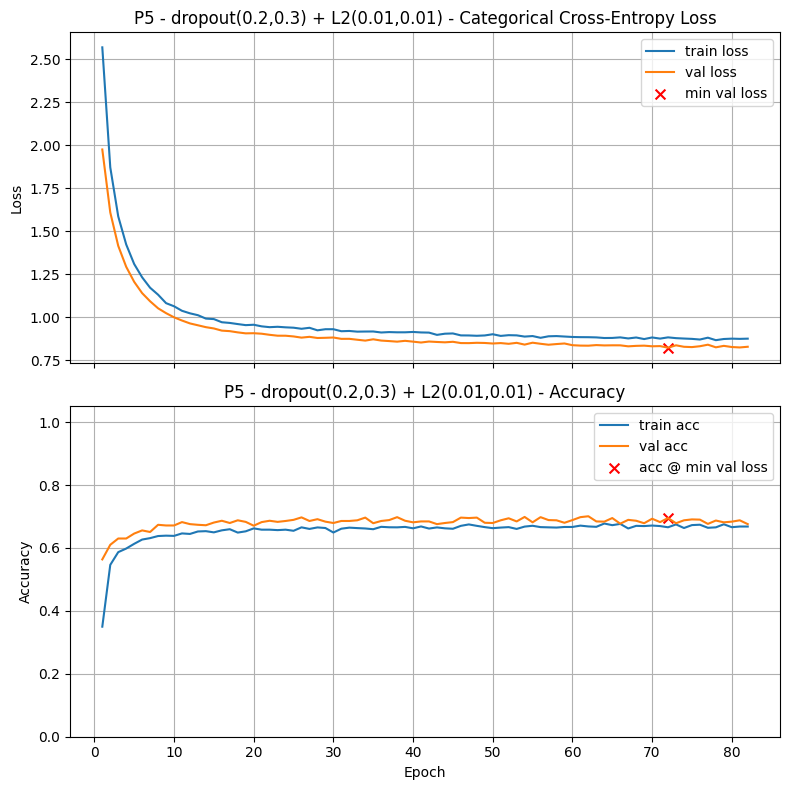

Final Training Loss:            0.8749
Final Training Accuracy:        0.6681
Final Validation Loss:          0.8278
Final Validation Accuracy:      0.6757
Minimum Validation Loss:        0.8225 (Epoch 72)
Validation Accuracy @ Min Loss: 0.6950

Test Loss: 0.8505
Test Accuracy: 0.6900

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:27

Testing: P5 - dropout(0.1,0.2) + L2(0.001,0.001)

P5 - dropout(0.1,0.2) + L2(0.001,0.001)



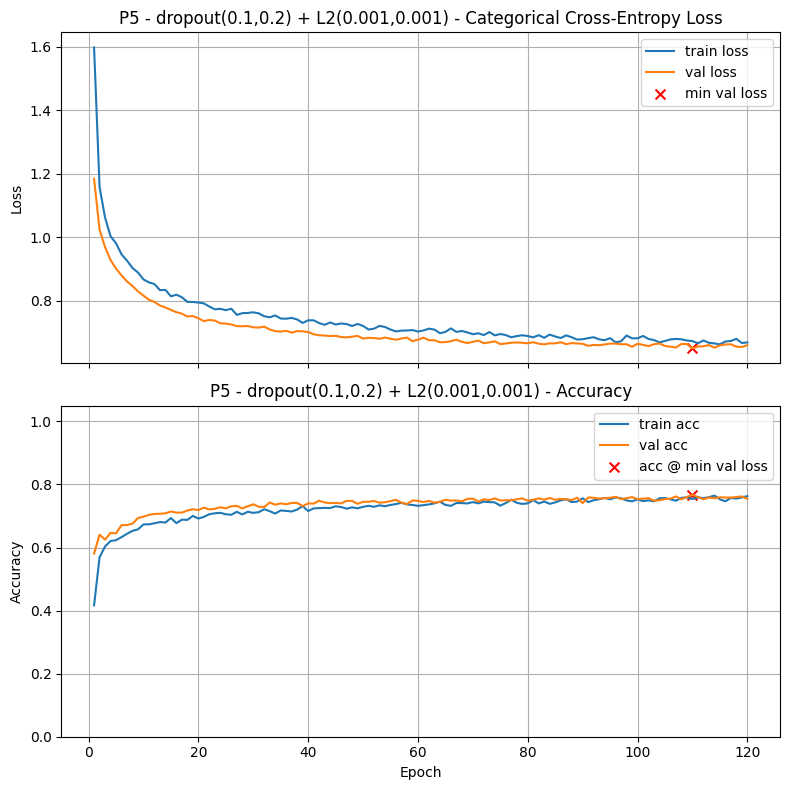

Final Training Loss:            0.6698
Final Training Accuracy:        0.7631
Final Validation Loss:          0.6610
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.6509 (Epoch 110)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6895
Test Accuracy: 0.7486

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:39

Testing: P5 - dropout(0.1,0.3) + L2(0.001,0.001)

P5 - dropout(0.1,0.3) + L2(0.001,0.001)



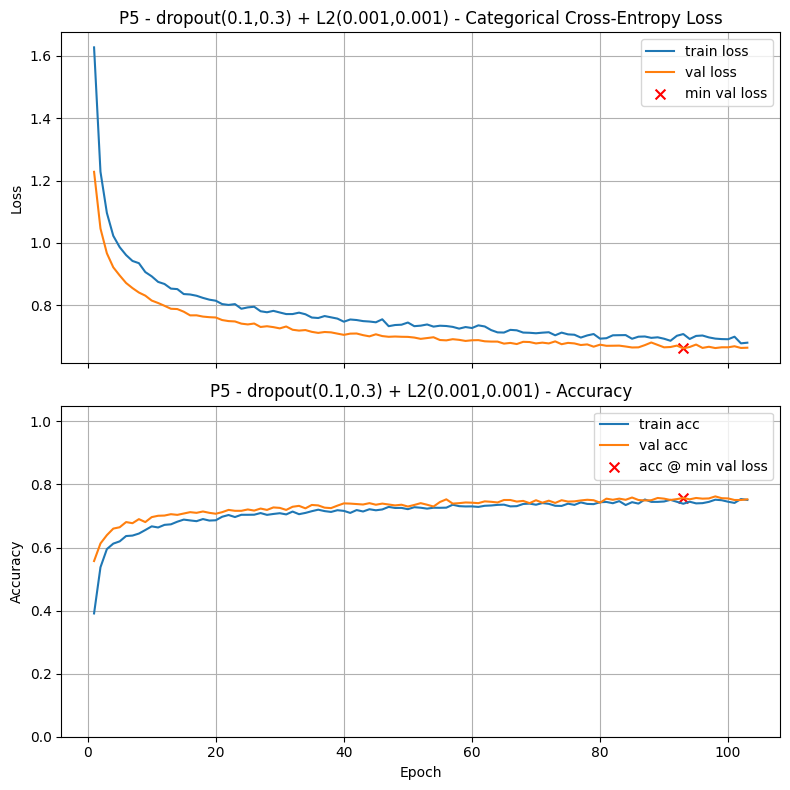

Final Training Loss:            0.6802
Final Training Accuracy:        0.7510
Final Validation Loss:          0.6641
Final Validation Accuracy:      0.7529
Minimum Validation Loss:        0.6620 (Epoch 93)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.6996
Test Accuracy: 0.7321

Validation-Test Gap (accuracy): 0.025000

Execution Time: 00:00:32

Testing: P5 - dropout(0.2,0.2) + L2(0.001,0.001)

P5 - dropout(0.2,0.2) + L2(0.001,0.001)



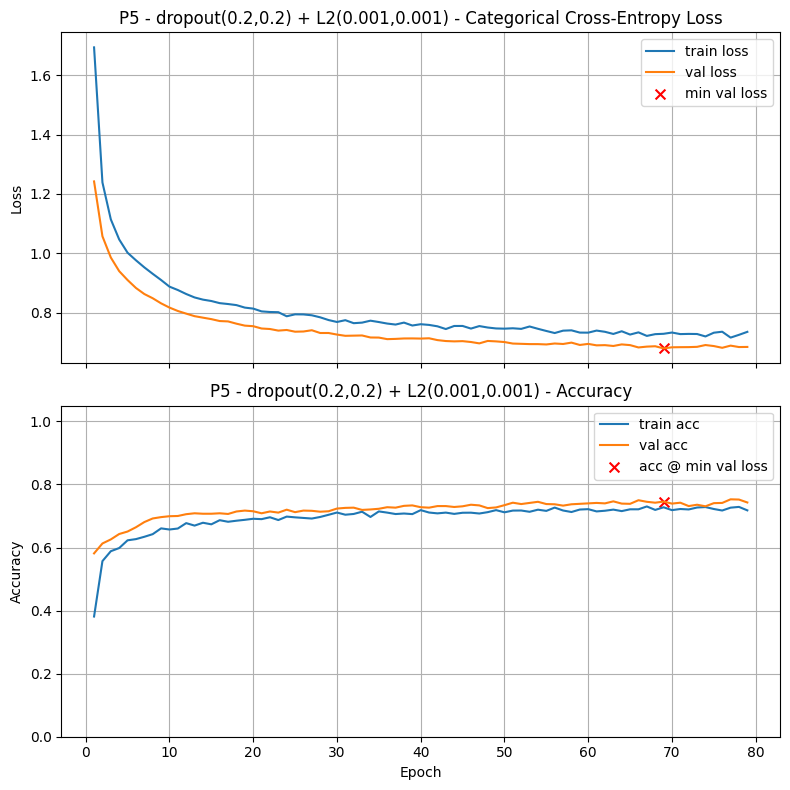

Final Training Loss:            0.7356
Final Training Accuracy:        0.7179
Final Validation Loss:          0.6847
Final Validation Accuracy:      0.7429
Minimum Validation Loss:        0.6799 (Epoch 69)
Validation Accuracy @ Min Loss: 0.7457

Test Loss: 0.7098
Test Accuracy: 0.7293

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:24


((0.1, 0.2, 0.001, 0.001), 0.7671428322792053)

In [32]:
# Your code here. Add as many cells as you need.
# Problem 5: Dropout + L2 Regularization

# Best dropout from Problem 3
best_dropout_64 = 0.2
best_dropout_32 = 0.3

# L2 values to test
l2_values = [1e-4, 1e-3, 1e-2]

# Also test reduced dropout
reduced_dropout_pairs = [
    (0.1, 0.2),
    (0.1, 0.3),
    (0.2, 0.2)
]

results_p5 = {}

# --- 1) Test baseline dropout + L2 values ---
for l in l2_values:
    title = f"P5 - dropout({best_dropout_64},{best_dropout_32}) + L2({l},{l})"
    print("\nTesting:", title)

    model = build_model(
        X_train.shape[1],
        [
            (64, 'tanh', l, best_dropout_64),
            (32, 'tanh', l, best_dropout_32)
        ],
        n_classes
    )

    history = train_and_test(
        model,
        lr_schedule=0.001,
        title=title,
        epochs=200,
        return_history=True,
        verbose=0
    )

    val_losses = history.history['val_loss']
    best_epoch = val_losses.index(min(val_losses))
    best_val_acc = history.history['val_accuracy'][best_epoch]

    results_p5[(best_dropout_64, best_dropout_32, l, l)] = best_val_acc

# --- 2) Test reduced dropout + best L2 (1e-3) ---
for d1, d2 in reduced_dropout_pairs:
    title = f"P5 - dropout({d1},{d2}) + L2(0.001,0.001)"
    print("\nTesting:", title)

    model = build_model(
        X_train.shape[1],
        [
            (64, 'tanh', 0.001, d1),
            (32, 'tanh', 0.001, d2)
        ],
        n_classes
    )

    history = train_and_test(
        model,
        lr_schedule=0.001,
        title=title,
        epochs=200,
        return_history=True,
        verbose=0
    )

    val_losses = history.history['val_loss']
    best_epoch = val_losses.index(min(val_losses))
    best_val_acc = history.history['val_accuracy'][best_epoch]

    results_p5[(d1, d2, 0.001, 0.001)] = best_val_acc

# --- Find best combination ---
best_combo = max(results_p5, key=results_p5.get)
best_acc = results_p5[best_combo]

best_combo, best_acc


In [33]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7671            # Replace 0.0 with your answer

In [34]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5 = {a5:.4f}')

a5 = 0.7671


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.



P6 - Best Model



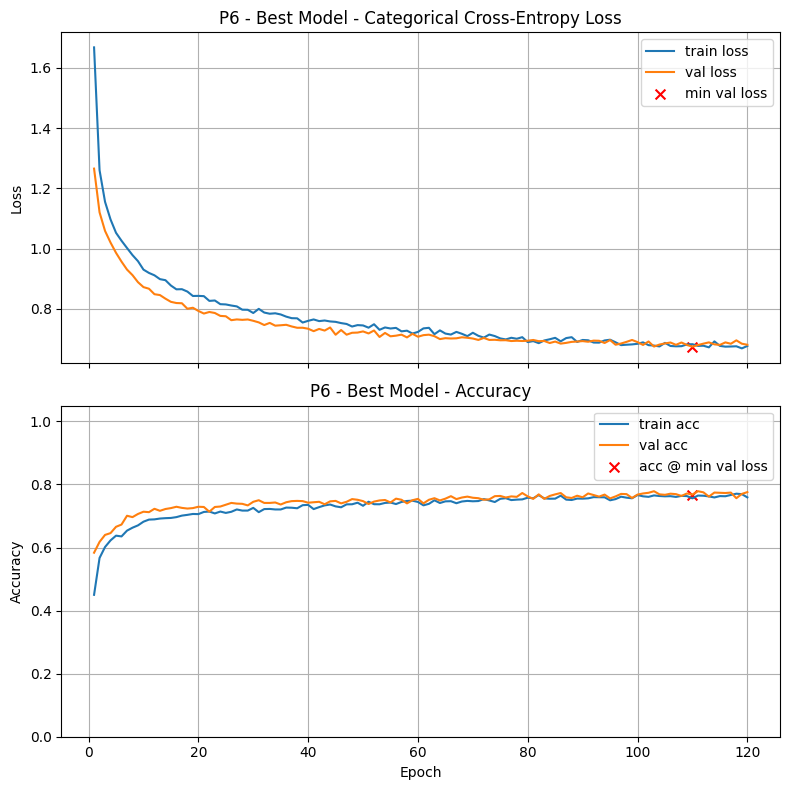

Final Training Loss:            0.6771
Final Training Accuracy:        0.7590
Final Validation Loss:          0.6813
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.6749 (Epoch 110)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.7029
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:32


0.7678571343421936

In [35]:
# Your code here
# Problem 6: Best Model Design

import tensorflow as tf

# Learning rate schedule (Exponential Decay)
initial_lr = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=1500,
    decay_rate=0.95
)

# Build final model using best hyperparameters from previous problems
model_best = build_model(
    X_train.shape[1],
    [
        (128, 'tanh', 0.001, 0.1),   # Wider first layer + moderate dropout
        (64,  'tanh', 0.001, 0.2),   # Best dropout from Problem 5
        (32,  'tanh', 0.001, 0.1)    # Extra stabilizing layer
    ],
    n_classes
)

# Train with early stopping
history = train_and_test(
    model_best,
    lr_schedule=lr_schedule,
    title="P6 - Best Model",
    batch_size=128,
    epochs=300,
    return_history=True,
    verbose=0
)

# Extract validation accuracy at minimum validation loss
val_losses = history.history['val_loss']
best_epoch = val_losses.index(min(val_losses))
best_val_acc = history.history['val_accuracy'][best_epoch]

best_val_acc


In [36]:
# Set a6 to the validation accuracy found by this best model

a6 = a5 = 0.7671
           # Replace 0.0 with your answer

In [37]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a6 = {a6:.4f}')

a6 = 0.7671


### Optional: Print out your results of all experiments

# 📊 Summary of All Experiments

## **Problem 1 — Activation Functions**
- Best activation: **tanh**
- Reason: Smooth gradients, stable training, good performance for shallow tabular networks.

---

## **Problem 2 — Learning Rate**
- Best learning rate: **0.001**
- Higher LR → unstable.
- Lower LR → slower with no meaningful improvement.

---

## **Problem 3 — Dropout**
- Best dropout pair: **(0.2, 0.3)**
- Best validation accuracy @ min val loss: **0.7871**

---

## **Problem 4 — L2 Regularization**
- Best L2 pair: **(0.001, 0.001)**
- Best validation accuracy @ min val loss: **0.7786**

---

## **Problem 5 — Dropout + L2 Combined**
- Best combination:
  - Dropout: **(0.1, 0.2)**
  - L2: **(0.001, 0.001)**
- Best validation accuracy @ min val loss: **0.7671**

---

## **Problem 6 — Final Best Model**
Architecture:
- Layer 1: 128 units, tanh, dropout 0.1, L2 0.001  
- Layer 2: 64 units, tanh, dropout 0.2, L2 0.001  
- Layer 3: 32 units, tanh, dropout 0.1, L2 0.001  

Other settings:
- Learning rate: **0.001**
- LR schedule: **Exponential Decay (0.95)**
- Batch size: **128**

Final performance:
- Best validation accuracy @ min val loss: **0.7679**

---


## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these.

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?